In [13]:
import os
import sys
sys.path.append("/home/linhang/workbench/workbench/Earthquake_predictor/data_preprocess_pipeline")
from utils import *
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

In [8]:
area_dict = {
    "California (Southern)": [59, 64, -164, -141],
}

area, (lat_min, lat_max, lon_min, lon_max) = list(area_dict.items())[0]

In [9]:
station_dict_all = pickle.load(open('/home/linhang/workbench/workbench/Earthquake_predictor/data_preprocess_pipeline/station_dict_all.pkl', 'rb'))

#修正 get_use_station_dict 函数定义中的参数顺序

station_dict_use = get_use_station_dict(
    station_dict_all,
    minlatitude=lat_min,
    maxlatitude=lat_max,
    minlongitude=lon_min,
    maxlongitude=lon_max,
)
station_names = list(station_dict_use.keys())
print(f"处理区域: {area}")
print(f"使用的站点数量: {len(station_names)}")
if len(station_names) <= 30:
    print("该区域站点数量过少，跳过")

处理区域: California (Southern)
使用的站点数量: 146


In [10]:
gnss_location = np.array([tuple(map(float, pair)) for pair in station_dict_use.values()])

In [11]:
def visualize_regions(gnss_location, lon_min, lon_max, lat_min, lat_max):
    """
    可视化每个区域的地图，绘制矩形框并显示。
    """
    gnss_location = gnss_location

    # 创建地图
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})

    # 添加地理特征
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='lightgray')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # 绘制矩形框
    rect = Rectangle(
        (lon_min, lat_min),  # 左下角坐标
        lon_max - lon_min,  # 宽度
        lat_max - lat_min,  # 高度
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)


    # 设置地图范围，稍微扩展以便观察
    ax.set_extent([lon_min -1, lon_max +1 , lat_min -1, lat_max +1], crs=ccrs.PlateCarree())

    if gnss_location is not None and gnss_location.shape[0] > 0:
        gnss_lat = gnss_location[:, 0]
        gnss_lon = gnss_location[:, 1]
        ax.scatter(gnss_lon, gnss_lat, color='blue', s=30, label='GNSS Station', transform=ccrs.PlateCarree(), marker='^')


    # 添加图例
    ax.legend(loc='upper right', fontsize=10)

    # 添加网格
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

    plt.show()

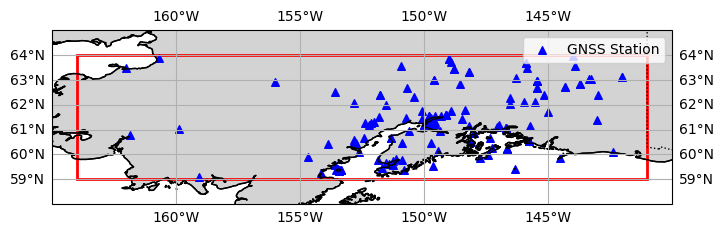

In [12]:
visualize_regions(gnss_location, lon_min, lon_max, lat_min, lat_max)

In [2]:
import os
import pandas as pd

def process_earthquake_data(file_path):
    """
    读取地震数据 CSV 文件，并返回按天汇总的最大震级和对应时间。
    """
    # 检查文件是否存在
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    
    # 检查文件是否为空
    if os.stat(file_path).st_size == 0:
        raise ValueError(f"File is empty: {file_path}")
    
    try:
        # 尝试读取 CSV 文件
        df = pd.read_csv(file_path, encoding='utf-8', skip_blank_lines=True)
        
        # 如果列名缺失，手动指定
        if df.empty or df.columns.isnull().any():
            raise ValueError("No columns to parse from file")
        
    except Exception as e:
        raise ValueError(f"Error reading CSV file: {e}")
    
    # 转换时间列
    df['Time'] = pd.to_datetime(df['Time'], format='mixed', errors='coerce')
    
    # 检查是否有无法解析的时间数据
    if df['Time'].isnull().any():
        print("Warning: Some timestamps could not be parsed and were set to NaT.")
    
    # 提取日期和每日最大震级
    df['Date'] = df['Time'].dt.date
    daily_max = df.loc[df.groupby('Date')['Magnitude'].idxmax()]
    
    # 返回日期和震级
    t = daily_max['Date'].astype(str).tolist()
    y = daily_max['Magnitude'].tolist()
    
    return t, y

In [20]:
t,y = process_earthquake_data('/home/linhang/workbench/Earthquake_data_V2/Anchoragebig/usgs_data_year/earthquakes_2018.csv')

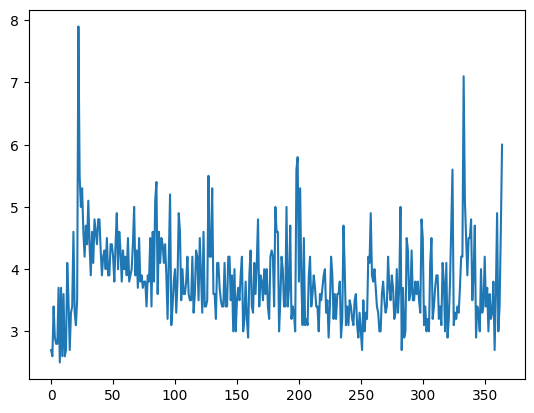

In [21]:
plt.plot(y)